In [1]:
import sys
from pathlib import Path

parent_folder = Path.cwd().parent
if str(parent_folder) not in sys.path:
    sys.path.append(str(parent_folder))
    
import warnings
warnings.filterwarnings('ignore')

import scienceplots

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('science')
from analysis import Analysis

PyHEADTAIL v1.16.5


# Diagnostic tool

In [2]:
def show_beam(analysis, turn=0):
    fig, axs=plt.subplots(2, figsize=(20,12))
    axs[0].plot(np.mean(analysis.x, axis=0)[50*turn:50*(turn+1)], c='b')
    axs[0].plot((np.mean(analysis.x, axis=0)
                 +np.std(analysis.x, axis=0))[50*turn:50*(turn+1)], c='b', ls='--')
    axs[0].plot((np.mean(analysis.x, axis=0)
                 -np.std(analysis.x, axis=0))[50*turn:50*(turn+1)], c='b', ls='--')
        
    axs[0].plot(analysis.x_pipe + analysis.x_length/2, c='k')
    axs[0].plot(analysis.x_pipe - analysis.x_length/2, c='k')
    axs[0].plot(analysis.x0, c='r')
    axs[0].plot(analysis.x0 + analysis.sigma_x, c='r', ls='--')
    axs[0].plot(analysis.x0 - analysis.sigma_x, c='r', ls='--')

    
    axs[1].plot(np.mean(analysis.y, axis=0)[50*turn:50*(turn+1)], c='b')
    axs[1].plot((np.mean(analysis.y, axis=0)
                 +np.std(analysis.y, axis=0))[50*turn:50*(turn+1)], c='b', ls='--')
    axs[1].plot((np.mean(analysis.y, axis=0)
                 -np.std(analysis.y, axis=0))[50*turn:50*(turn+1)], c='b', ls='--')
    axs[1].plot(analysis.y_pipe + analysis.y_length/2, c='k')
    axs[1].plot(analysis.y_pipe - analysis.y_length/2, c='k')
    axs[1].plot(analysis.y0, c='r')
    axs[1].plot(analysis.y0 + analysis.sigma_y, c='r', ls='--')
    axs[1].plot(analysis.y0 - analysis.sigma_y, c='r', ls='--')

    axs[0].set_ylabel('1 sigma x beam in pipe')
    axs[1].set_ylabel('1 sigma y beam in pipe')
    plt.show()

# No SC

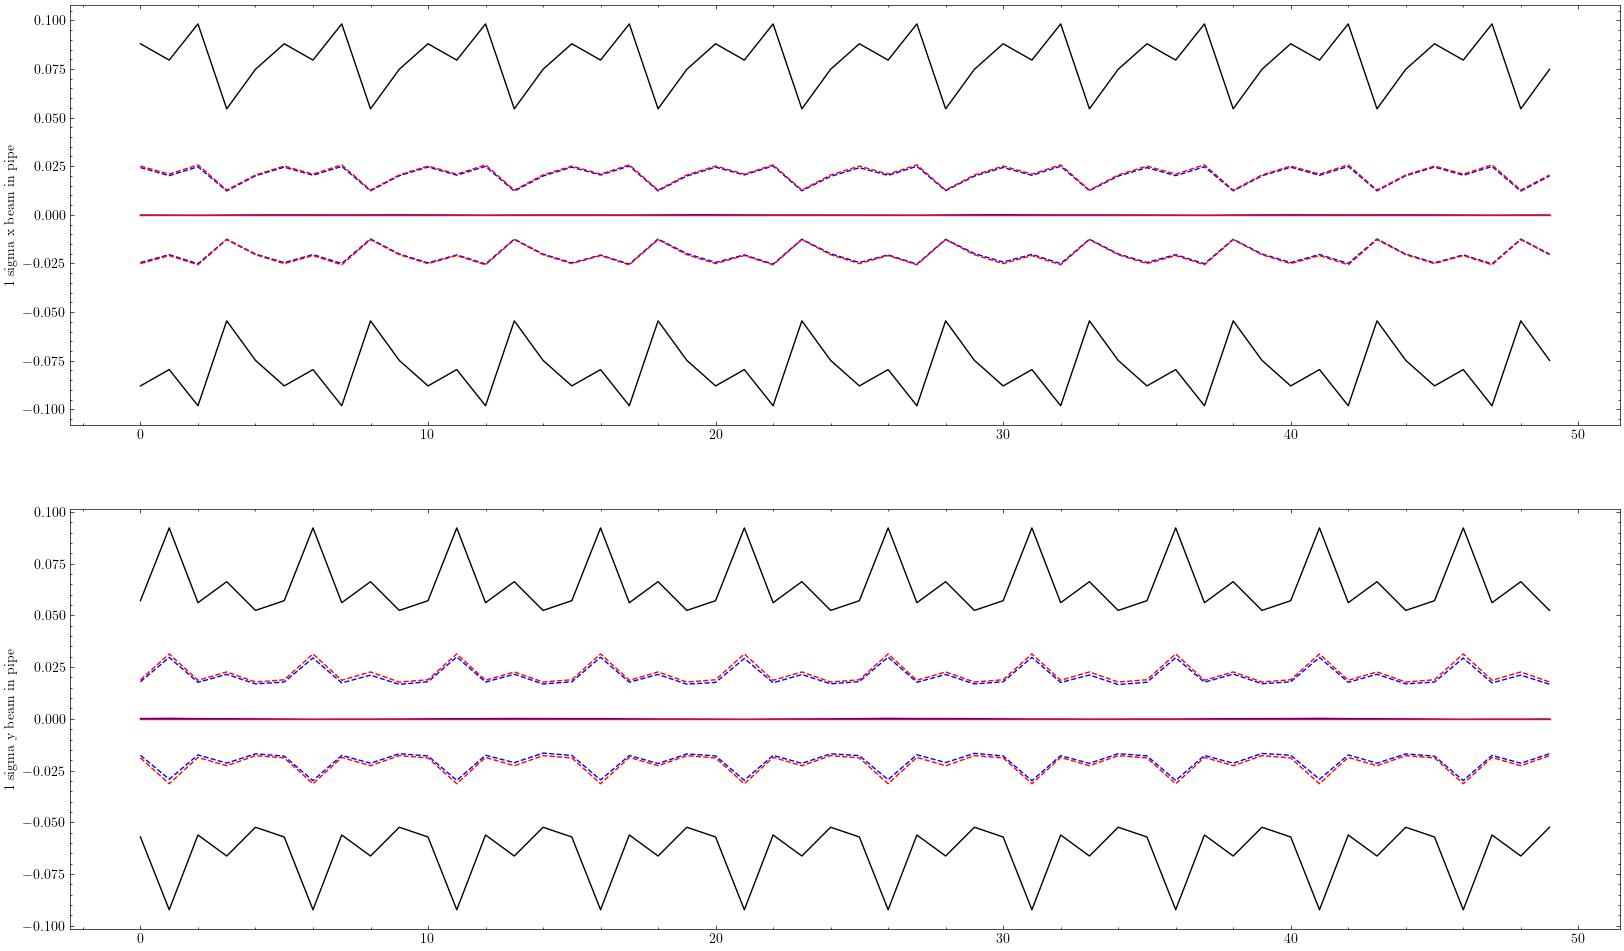

In [3]:
analysis = Analysis('data/default/no_sc')
#analysis.tune_histogram(x_lims=(3.6,4.4), y_lims=(3.0,3.8))
show_beam(analysis, turn=40)

# Direct SC

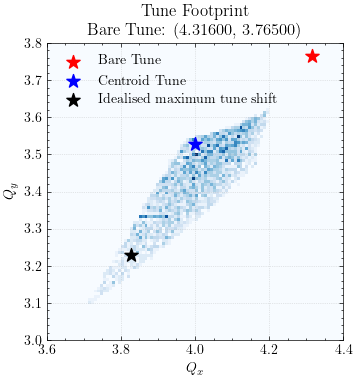

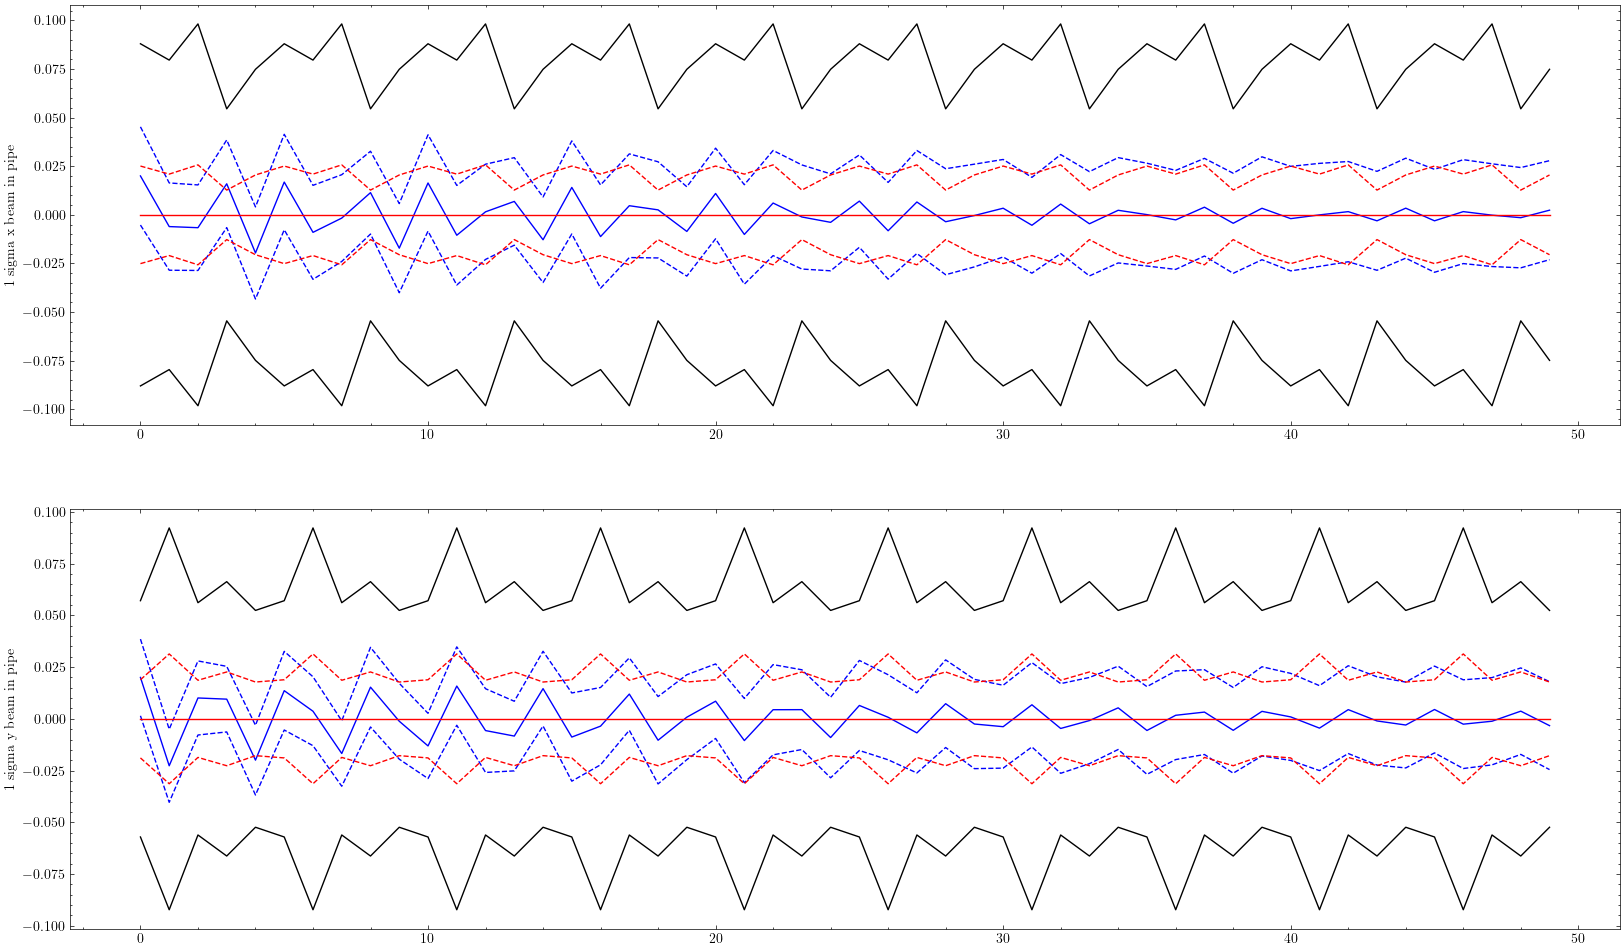

3979


In [79]:
analysis = Analysis('data/default/dir_sc_pert_bigger')
analysis.tune_histogram(x_lims=(3.6,4.4), y_lims=(3.0,3.8), centroid=True)
show_beam(analysis, turn=0)

print(np.sum(analysis.survivor_mask))

# Indirect SC

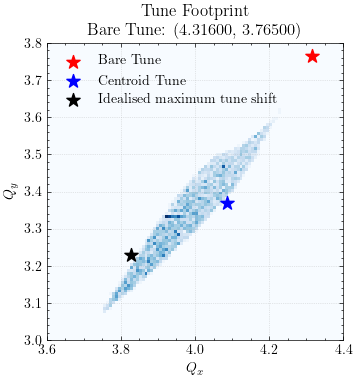

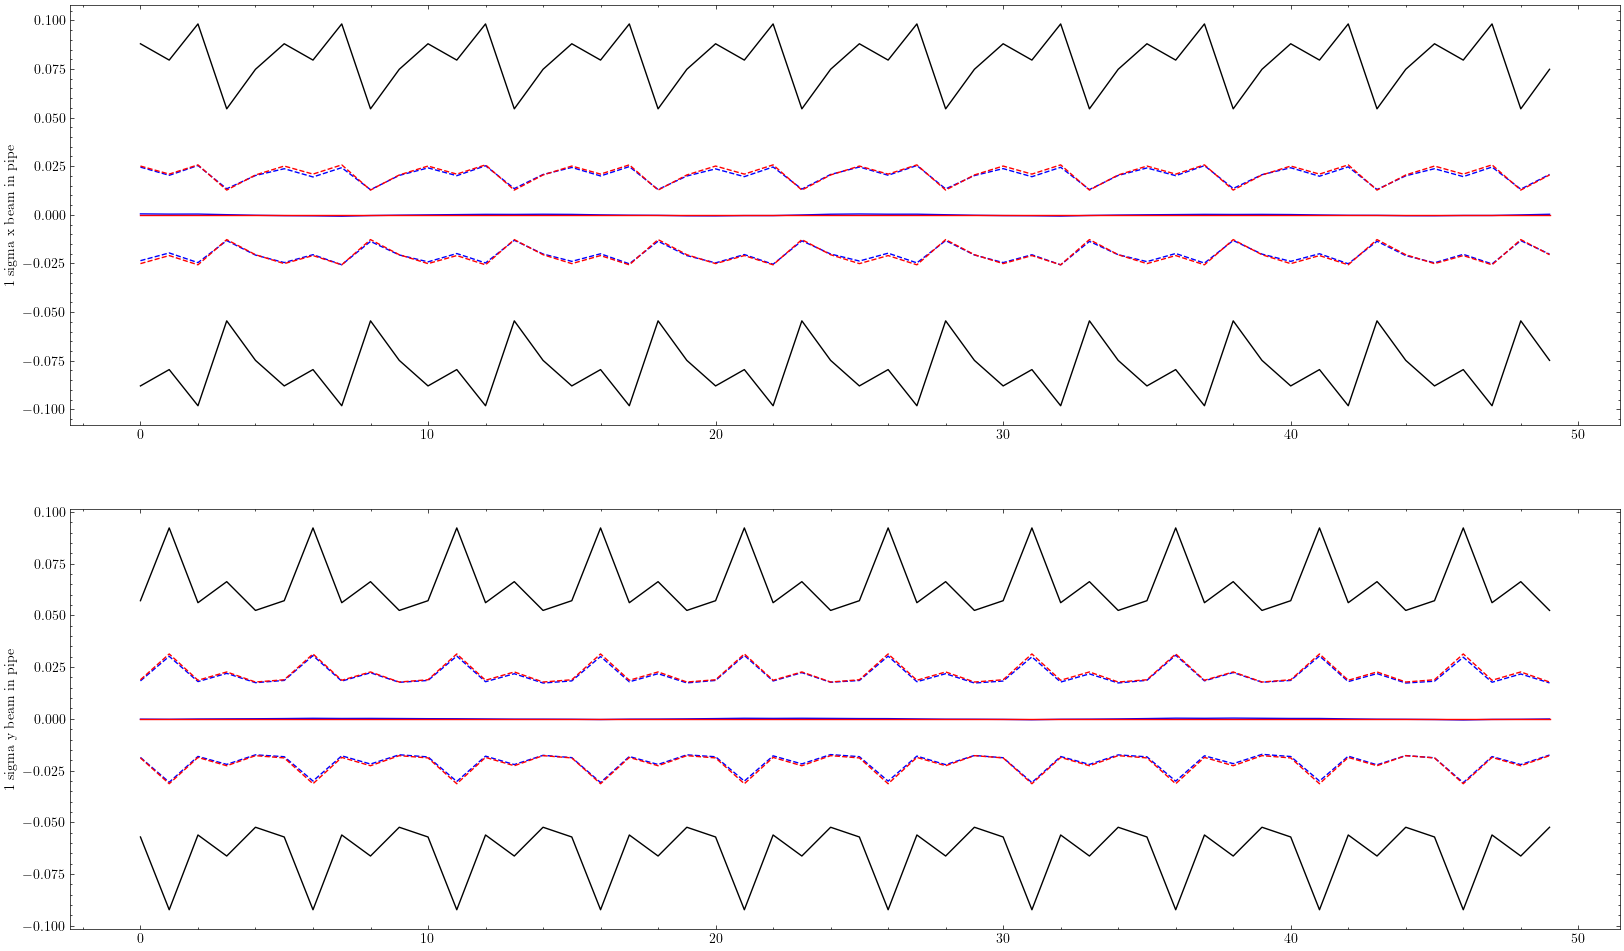

In [5]:
analysis = Analysis('data/default/ind_sc')

analysis.tune_histogram(x_lims=(3.6,4.4), y_lims=(3.0,3.8), centroid=True)
show_beam(analysis, turn=10)

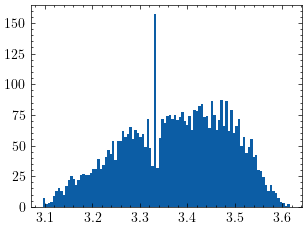

In [77]:
Qy = [i for i in analysis.Qy if i>1]
a, b, c = plt.hist(Qy, bins=100)

In [78]:
ind = np.argmax(a)
print(b[ind])

3.3296477099021184


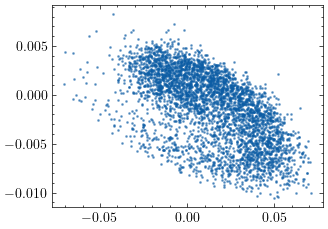

In [85]:
step = 20
x = analysis.x.T[step]
px = analysis.px.T[step]
plt.scatter(x, px, alpha=0.5, s=1)

In [9]:
#for particle in range(1000):
#    if not (3.33<analysis.Qy[particle]<3.337):
#        x = analysis.x[particle][::10]
#        px = analysis.px[particle][::10]
#        plt.scatter(x, px, alpha=0.5, s=1)
#        plt.title(f'Qy = {analysis.Qy[particle]} - ind={particle}')
#        plt.show()

[3.91197327 3.88593176 3.93801666 2.75469167]


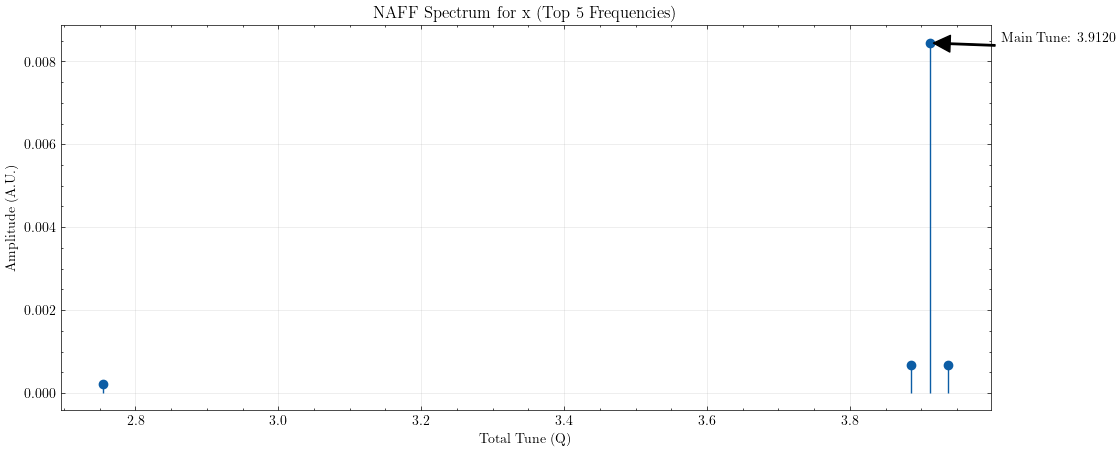

In [54]:
analysis.plot_spectrum('x')

4.0


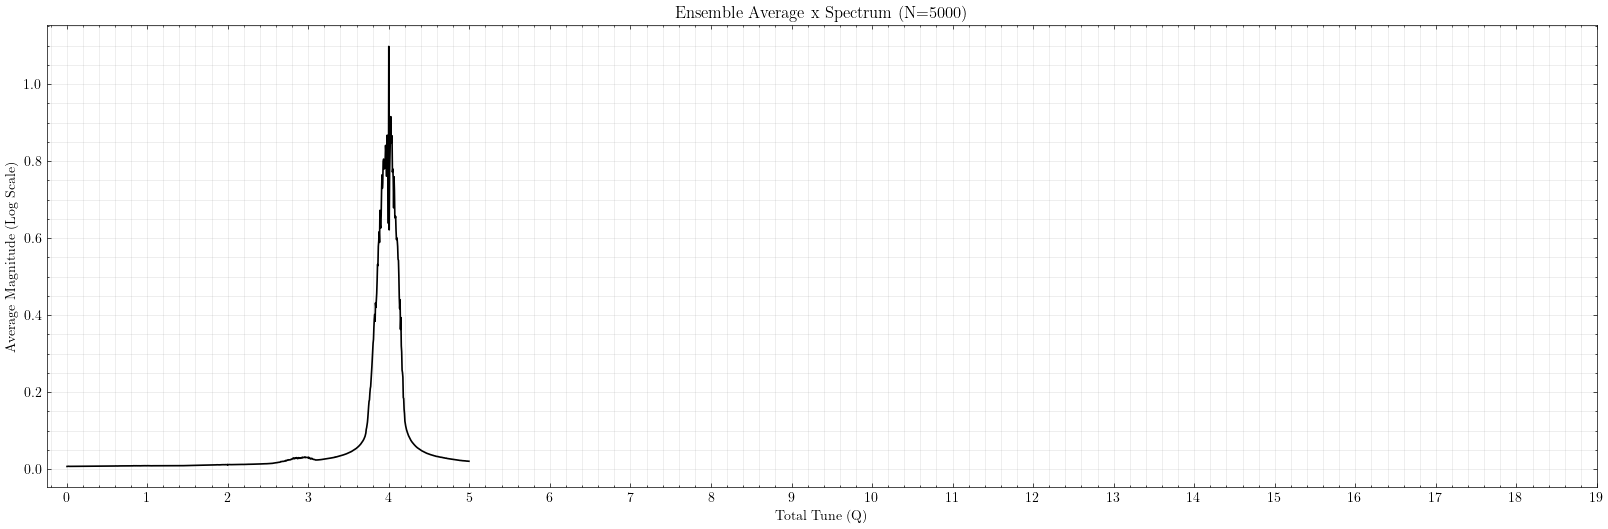

In [53]:
analysis.plot_ensemble_fft_spectrum('x')

In [12]:
print(analysis.get_tune('x', centroid=True))
print(analysis.get_tune('y', centroid=True))

4.086827055427418
3.3692400062145382


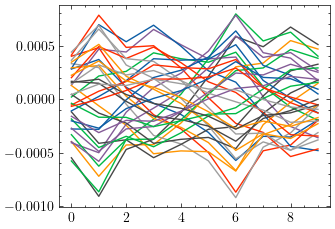

In [28]:
for i in range(10,45):
    plt.plot(np.mean(analysis.y, axis=0)[10*i:10*(i+1)])

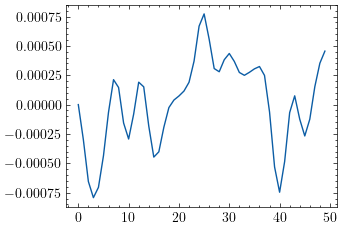

In [29]:
plt.plot(np.mean(analysis.x, axis=0)[::50])

In [88]:
x = np.mean(analysis.x, axis=0)
y = np.mean(analysis.px, axis=0)

z = x-1j*y
z = z-np.mean(z)
qx = nafflib.get_tune(z) * analysis.n_monitors
print(qx)

4.000595260221499


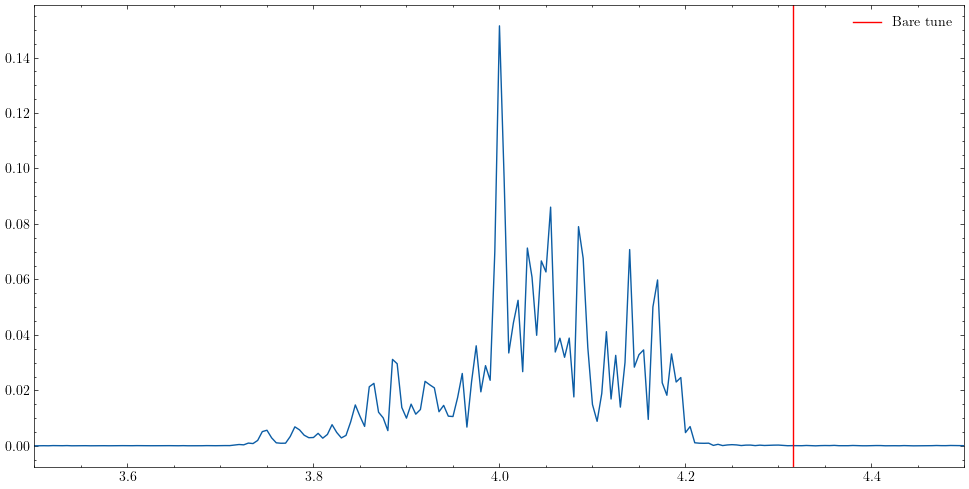

In [90]:
x = np.mean(analysis.x, axis=0)
N = len(x)
    
x = x - np.mean(x)

window = np.hanning(N)
x = x * window

fft_values = np.fft.rfft(x)
frequencies = np.fft.rfftfreq(N) * 10

amplitude = np.abs(fft_values)

fig, ax = plt.subplots(1, figsize=(12,6))
ax.plot(frequencies, amplitude)
ax.set_xlim(3.5, 4.5)
ax.axvline(x=4.316, color='red', label='Bare tune')
plt.legend()

In [24]:
import nafflib

# x and px and the position and momenta of 1 particle tracked around the machine
# they should have length N_monitors_per_turn * N_turns
z = x - 1j*px
signal = z - np.mean(z)
qx = nafflib.get_tune(signal) * N_monitors_per_turn
# qx is the tune of this particle





z = analysis.df_twiss.y - 1j*analysis.df_twiss.py
signal = z - np.mean(z)
qy = nafflib.get_tune(signal) * len(analysis.df_twiss)

print(qx)
print(qy)

4.505768885240643
-1.032958984375
